In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Iris dataset

In [3]:
from sklearn.datasets import load_iris

#Import Iris Datasets

In [4]:
iris = load_iris(as_frame = True)

In [5]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [13]:
print(iris)

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns], 'target': 0      0
1      0
2 

In [6]:
df = iris.frame

In [7]:
df.shape

(150, 5)

In [8]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [11]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [14]:
target_names = dict(enumerate(iris.target_names))

In [15]:
print(enumerate(iris.target_names))

In [16]:
df["Species"] = df["target"].map(target_names)

In [17]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [18]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [19]:
# Quick Pandas inspection
print("\n📐 Shape:", df.shape)
print("-"*50)
print("\nℹ️ Info:")
print(df.info())
print("-"*50)
print("\n📊 Describe (numeric):")
print(df.describe())


📐 Shape: (150, 6)
--------------------------------------------------

ℹ️ Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   Species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
--------------------------------------------------

📊 Describe (numeric):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000       

In [20]:
# convert to numpy arrays
feature_cols = iris.feature_names
X = df[feature_cols]
Y = df["target"]

In [21]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [22]:
print(type(Y))

<class 'pandas.core.series.Series'>


In [23]:
print(X)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [24]:
print(type(Y))

<class 'pandas.core.series.Series'>


In [25]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64


In [26]:
X = X.to_numpy()
Y = Y.to_numpy()

In [27]:
# NumPy stats (column-wise): mean, std
col_means = X.mean(axis=0)
col_stds  = X.std(axis=0, ddof=0)  # population std (ddof=0)
print("\n🧮 NumPy column means:", col_means)
print("🧮 NumPy column stds :", col_stds)


🧮 NumPy column means: [5.84333333 3.05733333 3.758      1.19933333]
🧮 NumPy column stds : [0.82530129 0.43441097 1.75940407 0.75969263]


In [28]:
print("Missing values in the dataframe:")
print(df.isnull().sum())

Missing values in the dataframe:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
Species              0
dtype: int64


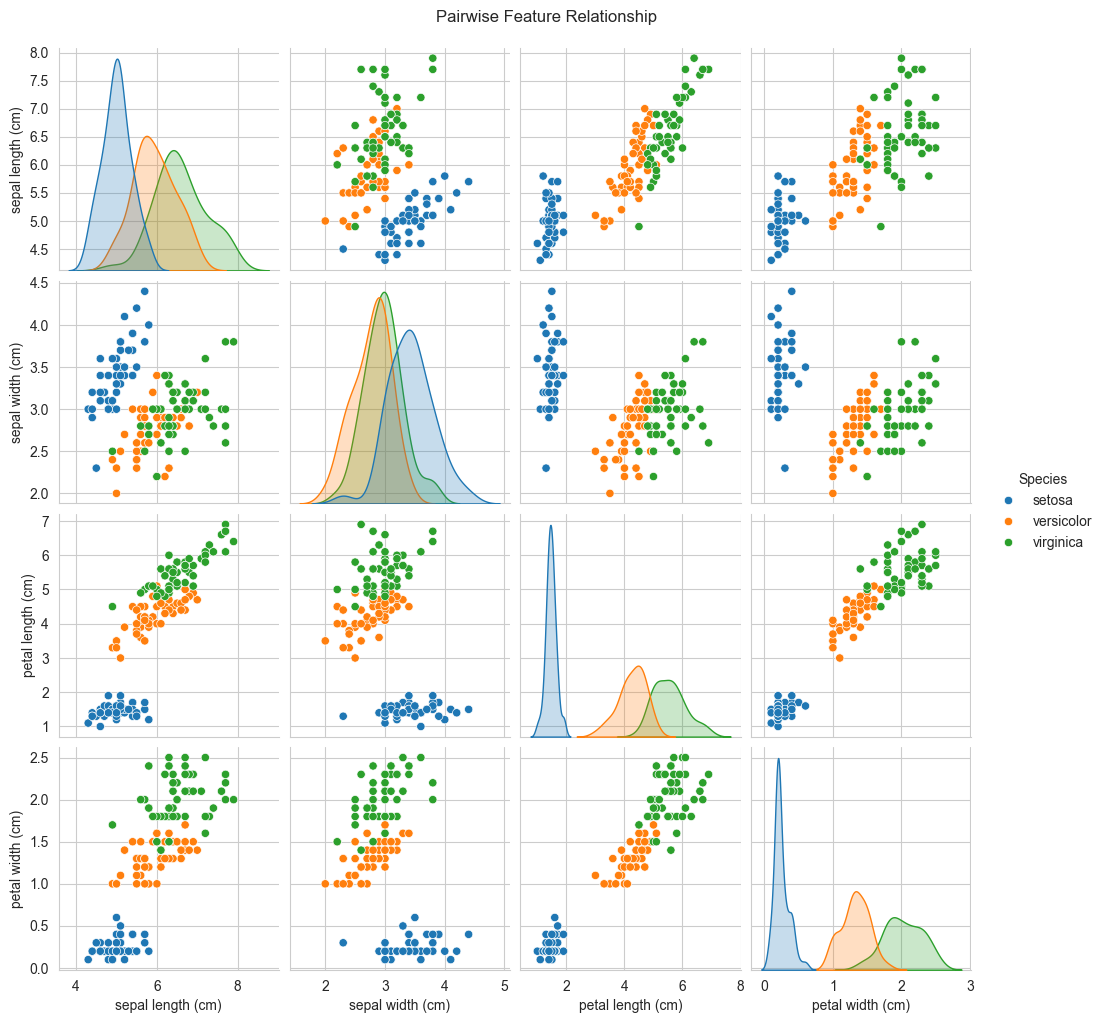

In [29]:
# pair plot with seaborn
sns.set_style("whitegrid")

sns.pairplot(df[feature_cols + ["Species"]], hue="Species", diag_kind="kde")
plt.suptitle("Pairwise Feature Relationship", y=1.02)
plt.show()

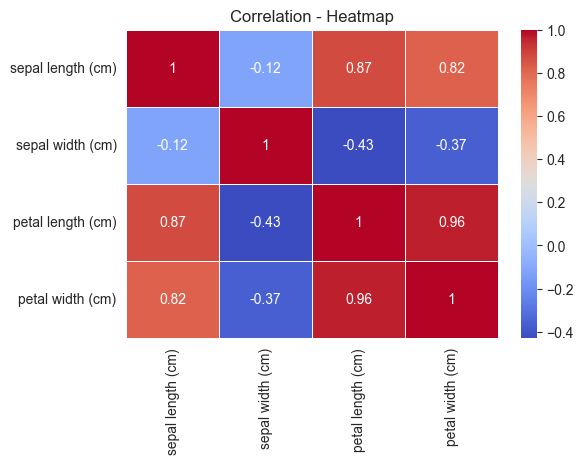

In [30]:
# correlation heatmap
corr = df[feature_cols].corr(numeric_only=True)
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation - Heatmap")
plt.show()

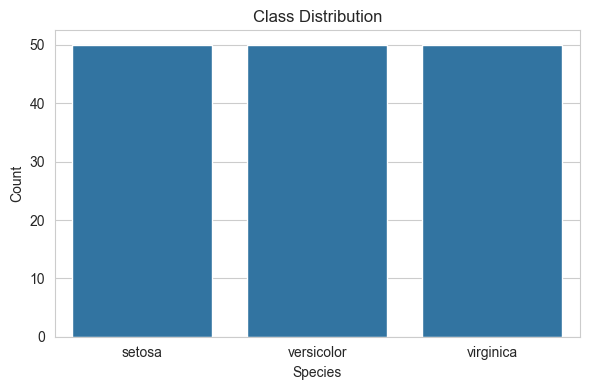

In [31]:
# Class distribution bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x="Species", data=df)
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

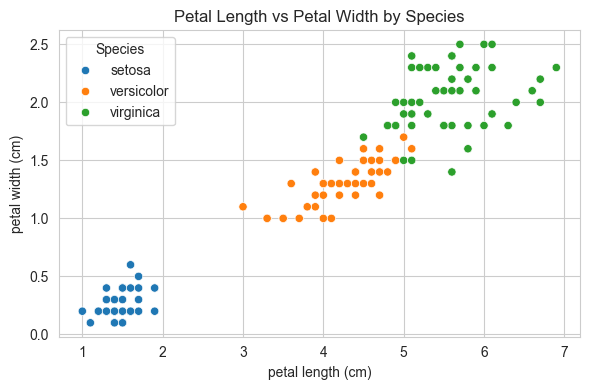

In [32]:
# Simple scatter with hue (example: petal length vs petal width)
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Species"
    )
plt.title("Petal Length vs Petal Width by Species")
plt.tight_layout()
plt.show()